kapital 4 fråga 12

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

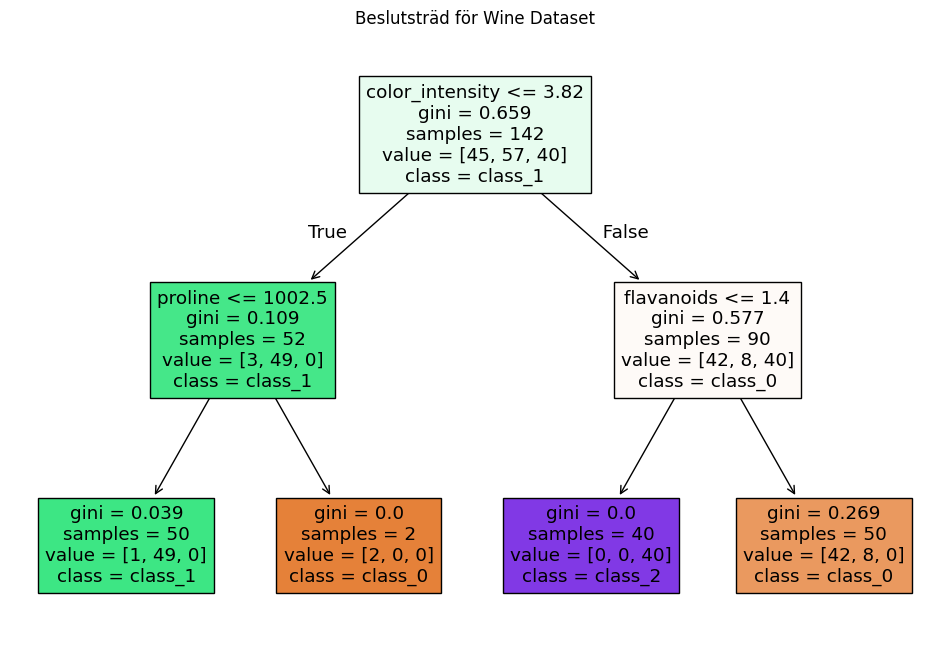

In [1]:
# kapitak 4 fråga 12
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split # fråga Antonio om det är ok att använda
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
# Ladda data
data = load_wine()
print(data.DESCR)

# Gör om till DataFrame + lägg till target
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Dela upp i X och y
X = df.drop("target", axis=1)
y = df["target"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Skapa och träna modellen
tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
# Visualisera trädet
plt.figure(figsize=(12, 8))
plot_tree(tree_clf,
          filled=True,
          feature_names=data.feature_names,
          class_names=data.target_names)

plt.title("Beslutsträd för Wine Dataset")
plt.show()

kapital 4 fråga 13

In [2]:
# kapitak 4 fråga 13
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Läs in data
df = pd.read_excel("hr_employee_data.xlsx")

# One-hot encode
df = pd.get_dummies(df, columns=["Department", "salary"], drop_first=True)

# Definiera X och y
X = df.drop(columns=["Emp_Id", "left"])
y = df["left"]


#Dela upp i train/test/validation
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

# Skala datan
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#Logistic Regression
modell = LogisticRegression()
modell.fit(X_train, y_train)
y_pred = modell.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))



target_names = ['class 0', 'class 1']

print(classification_report(y_test, y_pred, target_names=target_names))


#Random Forest
modell_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modell_rf.fit(X_train, y_train)
y_pred_rf = modell_rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))






Logistic Regression Accuracy: 0.7853333333333333
              precision    recall  f1-score   support

     class 0       0.82      0.92      0.87      2294
     class 1       0.58      0.34      0.42       706

    accuracy                           0.79      3000
   macro avg       0.70      0.63      0.65      3000
weighted avg       0.76      0.79      0.76      3000

Random Forest Accuracy: 0.985


kapital 4 fråga 14

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

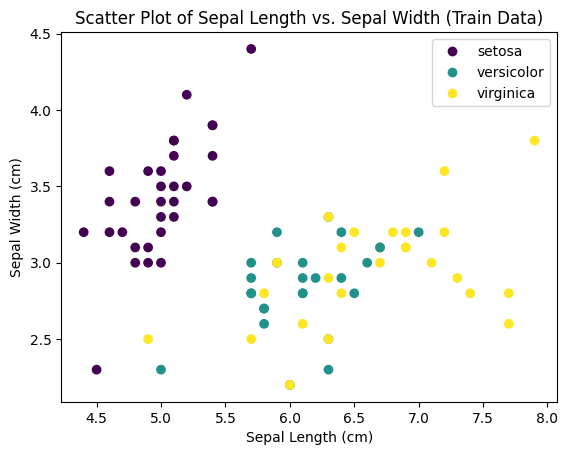

In [3]:
# fråga 14 kapital 4
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()
print(iris.DESCR)
print(iris.target_names)

X, y = load_iris(return_X_y=True, as_frame=True)

# Only choose two variables for the modelling to keep it simple
X = X[['sepal length (cm)', 'sepal width (cm)']]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=36)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=200)
tree = DecisionTreeClassifier(random_state=42)

logreg.fit(X_train, y_train)
tree.fit(X_train, y_train)

# Validering
acc_logreg = accuracy_score(y_val, logreg.predict(X_val))
acc_tree = accuracy_score(y_val, tree.predict(X_val))

print(f"Accuracy (LogReg): {acc_logreg:.2f}")
print(f"Accuracy (Tree): {acc_tree:.2f}")

# Välj bästa modell
if acc_logreg > acc_tree:
    best_model = LogisticRegression(max_iter=200)
    print("Logistic Regression är bäst")
else:
    best_model = DecisionTreeClassifier(random_state=42)
    print("Decision Tree är bäst")

# Träna på hela träningsdata
best_model.fit(X_train_full, y_train_full)

# Testa
y_test_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Träna på ALL data (sista steget)
best_model.fit(X, y)



classes = ['setosa', 'versicolor', 'virginica']

scatter = plt.scatter(
    X_train['sepal length (cm)'],
    X_train['sepal width (cm)'],
    c=y_train)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=classes
)

In [4]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_val)

In [5]:
tree_clf = DecisionTreeClassifier()

# Finding the best hyperparameter through GridSearch.
hyper_params = {'max_depth':(None, 1, 2, 5, 10)}
clf = GridSearchCV(tree_clf, hyper_params)

clf.fit(X_train, y_train)
clf_pred = clf.predict(X_val)

In [6]:
print(clf.best_params_)
pd.DataFrame(clf.cv_results_)

{'max_depth': 2}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000498,0.000152,0.000349,0.000095,None,{'max_depth': None},0.588235,0.647059,0.764706,0.764706,0.6250,0.677941,0.073294,3
1,0.000350,0.000017,0.000284,0.000013,1,{'max_depth': 1},0.647059,0.705882,0.705882,0.647059,0.5625,0.653676,0.052634,5
2,0.000375,0.000073,0.000293,0.000032,2,{'max_depth': 2},0.764706,0.647059,0.823529,0.882353,0.6250,0.748529,0.099349,1
3,0.000357,0.000040,0.000276,0.000009,5,{'max_depth': 5},0.705882,0.647059,0.823529,0.823529,0.5625,0.712500,0.101471,2
4,0.000357,0.000017,0.000274,0.000008,10,{'max_depth': 10},0.529412,0.647059,0.764706,0.764706,0.6250,0.666176,0.089646,4
